In [14]:
import pandas as pd
import numpy as np
import pydicom
import cv2
import matplotlib.pyplot as plt
import os

In [15]:
LABELS_PATH = r"C:\Users\Arush\Downloads\stage_2_train_labels.csv\stage_2_train_labels.csv"
IMAGE_DIR = r"C:\Users\Arush\Downloads\stage_2_train_images"

labels = pd.read_csv(LABELS_PATH)

print("Total rows:", len(labels))
labels.head()

Total rows: 30227


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [16]:
print(labels["Target"].value_counts())

# Unique patients
all_ids = labels["patientId"].unique()
print("Total patients:", len(all_ids))

Target
0    20672
1     9555
Name: count, dtype: int64
Total patients: 26684


In [17]:
def get_boxes(patient_id):
    records = labels[labels['patientId'] == patient_id]

    boxes = []
    for _, row in records.iterrows():
        if row['Target'] == 1:
            x1 = row['x']
            y1 = row['y']
            x2 = x1 + row['width']
            y2 = y1 + row['height']
            boxes.append([x1, y1, x2, y2])

    return boxes

In [18]:
def load_image(path):
    dicom = pydicom.dcmread(path)
    img = dicom.pixel_array

    orig_h, orig_w = img.shape

    img = cv2.resize(img, (512, 512))
    img = img / 255.0

    return img, (orig_w, orig_h)

In [19]:
def show_image_with_boxes(patient_id):
    path = os.path.join(IMAGE_DIR, f"{patient_id}.dcm")

    img, (orig_w, orig_h) = load_image(path)
    boxes = get_boxes(patient_id)

    scale_x = 512 / orig_w
    scale_y = 512 / orig_h

    img_copy = img.copy()

    for box in boxes:
        x1, y1, x2, y2 = box

        x1 = int(x1 * scale_x)
        x2 = int(x2 * scale_x)
        y1 = int(y1 * scale_y)
        y2 = int(y2 * scale_y)

        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (1, 0, 0), 2)

    plt.imshow(img_copy, cmap='gray')
    plt.title(f"Patient ID: {patient_id}")
    plt.axis("off")
    plt.show()

In [21]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision

In [22]:
class RSNADataset(Dataset):
    def __init__(self, image_dir, labels_df, image_ids):
        self.image_dir = image_dir
        self.labels_df = labels_df
        self.image_ids = image_ids

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        patient_id = self.image_ids[idx]

        path = os.path.join(self.image_dir, f"{patient_id}.dcm")
        dicom = pydicom.dcmread(path)
        img = dicom.pixel_array.astype(np.float32)

        orig_h, orig_w = img.shape

        img = cv2.resize(img, (512, 512))
        img = img / 255.0

        img = torch.tensor(img).unsqueeze(0)

        records = self.labels_df[self.labels_df["patientId"] == patient_id]

        boxes = []
        for _, row in records.iterrows():
            if row["Target"] == 1:
                x1 = row["x"]
                y1 = row["y"]
                x2 = x1 + row["width"]
                y2 = y1 + row["height"]

                x1 = x1 * (512 / orig_w)
                x2 = x2 * (512 / orig_w)
                y1 = y1 * (512 / orig_h)
                y2 = y2 * (512 / orig_h)

                boxes.append([x1, y1, x2, y2])

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.ones((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return img, target

In [24]:
pos_ids = labels[labels["Target"] == 1]["patientId"].unique()
neg_ids = labels[labels["Target"] == 0]["patientId"].unique()

pos_sample = np.random.choice(pos_ids, 1000, replace=False)
neg_sample = np.random.choice(neg_ids, 1000, replace=False)

selected_ids = list(pos_sample) + list(neg_sample)

In [25]:
from sklearn.model_selection import train_test_split

train_ids, val_ids = train_test_split(selected_ids, test_size=0.2)

print(len(train_ids), len(val_ids))

1600 400


In [26]:
train_dataset = RSNADataset(IMAGE_DIR, labels, train_ids)
val_dataset = RSNADataset(IMAGE_DIR, labels, val_ids)

In [27]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

In [28]:
images, targets = next(iter(train_loader))

print(len(images))   # batch size
print(images[0].shape)  # should be (1, 512, 512)
print(targets[0])

4
torch.Size([1, 512, 512])
{'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}


In [29]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

num_classes = 2

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

c:\Users\Arush\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Arush\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\Arush/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:45<00:00, 3.72MB/s] 


In [33]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model.to(device)

print("Using:", device)
print(torch.cuda.get_device_name(0))
print(torch.cuda.is_available())

Using: cuda
NVIDIA GeForce RTX 4050 Laptop GPU
True


In [34]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [35]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for images, targets in train_loader:
        images = [img.to(device) for img in images]

        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 72.1074
Epoch 2, Loss: 67.8485
Epoch 3, Loss: 62.9977
Epoch 4, Loss: 57.2212
Epoch 5, Loss: 54.5617


In [36]:
def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    inter_area = max(0, xB - xA) * max(0, yB - yA)

    box1_area = (box1[2]-box1[0]) * (box1[3]-box1[1])
    box2_area = (box2[2]-box2[0]) * (box2[3]-box2[1])

    return inter_area / (box1_area + box2_area - inter_area + 1e-6)

In [37]:
model.eval()

iou_scores = []

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]

        outputs = model(images)

        for i in range(len(images)):
            preds = outputs[i]["boxes"].cpu().numpy()
            gts = targets[i]["boxes"].numpy()

            for gt in gts:
                best_iou = 0
                for pred in preds:
                    iou = compute_iou(pred, gt)
                    best_iou = max(best_iou, iou)

                iou_scores.append(best_iou)

In [38]:
mean_iou = sum(iou_scores) / len(iou_scores)
print("Mean IoU:", mean_iou)

Mean IoU: 0.6250362


In [39]:
threshold = 0.5

tp = sum(1 for iou in iou_scores if iou >= threshold)
fp = sum(1 for iou in iou_scores if iou < threshold)

precision = tp / (tp + fp + 1e-6)

print("Precision (AP @ IoU=0.5):", precision)

Precision (AP @ IoU=0.5): 0.8491803250846547


In [ ]:
import matplotlib.pyplot as plt

def show_predictions(model, dataset, device, idx=0, threshold=0.5):
    model.eval()

    img, target = dataset[idx]

    with torch.no_grad():
        prediction = model([img.to(device)])

    pred_boxes = prediction[0]["boxes"].cpu().numpy()
    scores = prediction[0]["scores"].cpu().numpy()

    img_np = img.squeeze().cpu().numpy()

    img_np = (img_np * 255).astype(np.uint8)
    img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)

    for box, score in zip(pred_boxes, scores):
        if score >= threshold:
            x1, y1, x2, y2 = map(int, box)

            cv2.rectangle(img_np, (x1, y1), (x2, y2), (255, 0, 255), 2)

            cv2.putText(
                img_np,
                f"pneumonia {score:.2f}",
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 255),
                2
            )

    plt.imshow(img_np)
    plt.title("Predicted Output")
    plt.axis("off")
    plt.show()

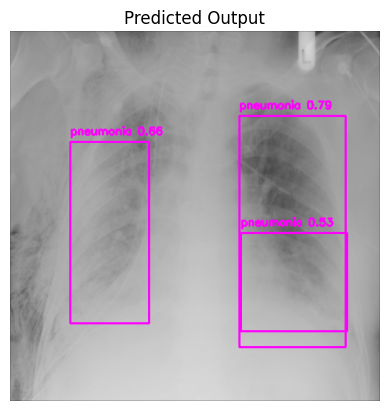

In [57]:
show_predictions(model, val_dataset, device, idx=0, threshold=0.5)